### 🔧 Step 1: Import Required Libraries

We begin by importing the necessary Python libraries for data handling, visualization, modeling, and evaluation.


In [1]:
!pip install xgboost

In [3]:
try:
    from xgboost import XGBRegressor
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    from sklearn.ensemble import RandomForestRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    import joblib



    print("✅ All libraries imported successfully.")
except ImportError as e:
    print(f"❌ Import error: {e}")


✅ All libraries imported successfully.


### 📥 Step 2: Load Player Dataset

We’ll load the main dataset from your local machine.  
Make sure the path is correct and the file is accessible.  
We'll also preview the first few rows to confirm successful loading.


In [5]:
try:
    
    file_path = r"C:\Users\nadza\OneDrive\Desktop\Tactic_Sense_Dataset\players_dataset.csv"
    df = pd.read_csv(file_path)
    print("✅ Dataset loaded successfully!")
    display(df.head())
except FileNotFoundError:
    print("❌ File not found. Please double-check the file path.")
except Exception as e:
    print(f"❌ Error loading dataset: {e}")


✅ Dataset loaded successfully!


,player_id,full_name,email,date_of_birth,age,nationality,position,secondary_position,club,league,...,skill_positioning,skill_finishing,skill_dribbling,skill_speed,skill_passing,skill_vision,skill_tackling,skill_marking,skill_heading,value_salary_ratio
0,1,Mamadou Diop,mamadou.diop@football.com,2003-01-01,22,senegal,goalkeeper,NaN,Linguère,Nigeria Professional Football League,...,78.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
1,2,Lamin Saidy,lamin.saidy@football.com,2003-03-29,21,gambia,goalkeeper,NaN,Waa Banjul,Nigeria Professional Football League,...,80.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
2,3,Issaka Oumarou,issaka.oumarou@football.com,2003-05-13,21,niger,goalkeeper,NaN,Gendarmerie Nationale,Nigeria Professional Football League,...,71.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
3,4,Joao Simbine,joao.simbine@football.com,2003-06-09,21,mozambique,goalkeeper,NaN,Ferroviário de Nampula,Nigeria Professional Football League,...,76.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0
4,5,Diogo Silva,diogo.silva@football.com,2003-06-16,21,portugal,goalkeeper,NaN,Vizela,Nigeria Professional Football League,...,83.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0


### 🧾 Step 3: Dataset Overview

We'll display basic information about the dataset:
- Data types and null values
- Basic statistics
- Count of missing values per column
- General data shape


In [4]:
try:
    print("🔍 Dataset Shape:", df.shape)
    print("\n🧠 Data Types and Non-Null Counts:")
    display(df.info())

    print("\n📊 Statistical Summary:")
    display(df.describe())

    print("\n❓ Missing Values per Column:")
    display(df.isnull().sum())
except Exception as e:
    print(f"❌ Error during EDA: {e}")


❌ Error during EDA: name 'df' is not defined


### 🔥 Step 4: Correlation Heatmap

This heatmap helps us identify the strength of linear relationships between numerical features, especially in relation to our target: `market_value`.

We'll use:
- `df.corr(numeric_only=True)` to filter only numeric columns.
- `seaborn` for the heatmap.


In [5]:
try:
    plt.figure(figsize=(12, 6))
    numeric_corr = df.corr(numeric_only=True)

    sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap of Numeric Features")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"❌ Error generating heatmap: {e}")


❌ Error generating heatmap: name 'df' is not defined


<Figure size 1200x600 with 0 Axes>

### 🧠 Step 5: Feature Engineering

We'll create a new **performance_score** feature that combines:
- Goals, Assists, Dribbles, and Mistakes

We’ll also:
- Ensure `position` and `league` are treated as categorical variables
- Check again for missing values


In [6]:
try:
    # Create performance_score using real columns
    df['performance_score'] = (
        df['goals'] * 4 +
        df['assists'] * 3 +
        df['profile_rating'] * 2 +
        df['scouting_score'] +
        df['tactic_fit_score'] -
        df['discipline_score']  # subtracting because more discipline issues = worse
    )

    # Handle categories
    df['position'] = df['position'].astype(str)
    df['league'] = df['league'].astype(str)

    top_positions = df['position'].value_counts().index[:5]
    df['position'] = df['position'].apply(lambda x: x if x in top_positions else 'Other')

    top_leagues = df['league'].value_counts().index[:5]
    df['league'] = df['league'].apply(lambda x: x if x in top_leagues else 'Other')

    print("✅ Feature engineering and category cleanup completed.")
    display(df[['goals', 'assists', 'profile_rating', 'scouting_score', 'discipline_score', 'performance_score']].head())

except Exception as e:
    print(f"❌ Error during feature engineering: {e}")


❌ Error during feature engineering: name 'df' is not defined


### 🎯 Step 6: Define Features (X) and Target (y)

We now isolate:
- `y`: the target variable – player `market_value`
- `X`: the features that will help predict it


In [11]:
try:
    # Load the new dataset
    df = pd.read_csv(r"C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\tactic_sense_app\data\players_dataset.csv")

    # Define the target
    y = df['market_value_eur']

    # Select features based on available columns
    selected_features = [
        'age', 'position', 'league',
        'goals', 'assists',
        'profile_rating', 'scouting_score', 'tactic_fit_score'
    ]
    X = df[selected_features]

    print("✅ Features and target set.")
    display(X.head())
except KeyError as e:
    print(f"❌ One of the selected columns was not found: {e}")
except Exception as e:
    print(f"❌ Error in defining features/target: {e}")



✅ Features and target set.


,age,position,league,goals,assists,profile_rating,scouting_score,tactic_fit_score
0,22,goalkeeper,Nigeria Professional Football League,0.0,0.0,65.12,47.98,90.67
1,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,88.44,64.61,75.48
2,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,73.36,54.05,78.80
3,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,83.66,61.26,66.67
4,21,goalkeeper,Nigeria Professional Football League,0.0,0.0,79.19,58.13,60.75


In [12]:
# Use log1p to avoid log(0) errors
df['log_market_value'] = np.log1p(df['market_value_eur'])

# Update target
y = df['log_market_value']


In [13]:
X = df[['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score', 'position', 'league']]


### 🧪 Step 7: Preprocessing & Modeling Pipeline (XGBoost)

In this step, we:
- Separate numerical and categorical features
- Build a preprocessing pipeline:
    - Standardize numerical features
    - One-hot encode categorical features
- Integrate everything into a full pipeline using `XGBRegressor`



In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

# 1. Define numeric and categorical feature lists
numeric_features = ['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score']
categorical_features = ['position', 'league']

# 2. Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# 3. Full pipeline with XGBoost model
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBRegressor(
        n_estimators=150,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        verbosity=0
    ))
])

print("✅ XGBoost pipeline created successfully.")


✅ XGBoost pipeline created successfully.


### 🏋️ Step 8: Train/Test Split & Model Training

We:
- Split the data into training and testing sets (80/20)
- Train the full pipeline (preprocessing + XGBoost)
- Target is in **log scale** (`log_market_value`)



In [15]:
from sklearn.model_selection import train_test_split

try:
    # Combine features
    X = df[numeric_features + categorical_features]

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Train the full pipeline
    pipeline.fit(X_train, y_train)

    print("✅ Model trained successfully with XGBoost and log-transformed target.")
except Exception as e:
    print(f"❌ Error during training: {e}")


✅ Model trained successfully with XGBoost and log-transformed target.


### 📊 Step 9: Model Evaluation (with log-transformed target)

We:
- Predict on the test set (still in log scale)
- Apply `np.expm1()` to get real market values
- Evaluate using MAE, RMSE, and R²
- Visualize predictions vs. actual values


📈 MAE:  938,500.51 EUR
📈 RMSE: 1,383,445.27 EUR
📈 R²:   0.229


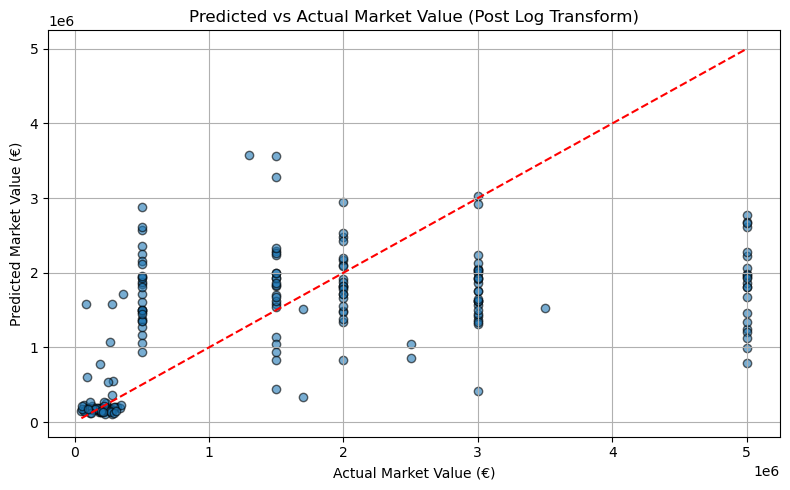

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

try:
    # Predict in log scale
    y_pred_log = pipeline.predict(X_test)

    # Convert back from log scale to real market value
    y_pred = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    r2 = r2_score(y_actual, y_pred)

    print(f"📈 MAE:  {mae:,.2f} EUR")
    print(f"📈 RMSE: {rmse:,.2f} EUR")
    print(f"📈 R²:   {r2:.3f}")

    # Scatter plot of actual vs predicted
    plt.figure(figsize=(8, 5))
    plt.scatter(y_actual, y_pred, alpha=0.6, edgecolor='k')
    plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--')
    plt.xlabel("Actual Market Value (€)")
    plt.ylabel("Predicted Market Value (€)")
    plt.title("Predicted vs Actual Market Value (Post Log Transform)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ Evaluation failed: {e}")


### 🧪 Step 10: Predict Market Value for a New Player (Custom Input)


In [17]:
try:
    new_player = pd.DataFrame([{
        'age': 21,
        'goals': 10,
        'assists': 5,
        'profile_rating': 8.5,
        'scouting_score': 86,
        'tactic_fit_score': 78,
        'position': 'Forward',
        'league': 'Premier League'
    }])

    predicted_log = pipeline.predict(new_player)[0]
    predicted_value = np.expm1(predicted_log)

    print(f"💸 Predicted Market Value: {predicted_value:,.2f} EUR")
except Exception as e:
    print(f"❌ Prediction failed: {e}")



💸 Predicted Market Value: 2,045,233.50 EUR


### 💾 Step 11: Export Trained XGBoost Model Pipeline


In [18]:
import joblib

try:
    save_path = r"C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\xgb_market_value_model.pkl"
    joblib.dump(pipeline, save_path)
    print(f"✅ Model saved to: {save_path}")
except Exception as e:
    print(f"❌ Error saving model: {e}")


✅ Model saved to: C:\Users\nadza\OneDrive\Desktop\tactic_sense_app\xgb_market_value_model.pkl


### 🧪 Step 14: Predict Market Value for a Single New Player (Custom Input)


In [19]:
test_players = pd.DataFrame([
    {
        'age': 19,
        'goals': 15,
        'assists': 7,
        'profile_rating': 9.2,
        'scouting_score': 91,
        'tactic_fit_score': 88,
        'position': 'Forward',
        'league': 'Premier League'
    },
    {
        'age': 34,
        'goals': 1,
        'assists': 2,
        'profile_rating': 6.0,
        'scouting_score': 48,
        'tactic_fit_score': 39,
        'position': 'Defender',
        'league': 'Other'
    },
    {
        'age': 26,
        'goals': 10,
        'assists': 12,
        'profile_rating': 8.0,
        'scouting_score': 79,
        'tactic_fit_score': 74,
        'position': 'Midfielder',
        'league': 'Turkish Super Lig'
    },
    {
        'age': 28,
        'goals': 0,
        'assists': 0,
        'profile_rating': 3.5,
        'scouting_score': 30,
        'tactic_fit_score': 20,
        'position': 'Other',
        'league': 'Regional Amateur League'
    },
    {
        'age': 25,
        'goals': 2,
        'assists': 1,
        'profile_rating': 5.0,
        'scouting_score': 40,
        'tactic_fit_score': 35,
        'position': 'Midfielder',
        'league': 'Serie B'
    },
    {
        'age': 20,
        'goals': 9,
        'assists': 6,
        'profile_rating': 8.7,
        'scouting_score': 85,
        'tactic_fit_score': 82,
        'position': 'Forward',
        'league': 'Tunisian Ligue 1'
    }
])

# Predict and reverse log transform
try:
    predicted_logs = pipeline.predict(test_players)
    predicted_values = np.expm1(predicted_logs)

    test_players['predicted_market_value_eur'] = predicted_values

    display(test_players[['position', 'league', 'age', 'goals', 'assists', 'profile_rating', 'predicted_market_value_eur']])
except Exception as e:
    print(f"❌ Prediction failed: {e}")


,position,league,age,goals,assists,profile_rating,predicted_market_value_eur
0,Forward,Premier League,19,15,7,9.2,1.927831e+06
1,Defender,Other,34,1,2,6.0,1.425190e+06
2,Midfielder,Turkish Super Lig,26,10,12,8.0,1.072745e+05
3,Other,Regional Amateur League,28,0,0,3.5,1.382920e+06
4,Midfielder,Serie B,25,2,1,5.0,1.375852e+06
5,Forward,Tunisian Ligue 1,20,9,6,8.7,1.917449e+06


In [20]:
try:
    unknown_player = pd.DataFrame([{
        'age': 27,
        'goals': 0,
        'assists': 0,
        'profile_rating': 4.0,
        'scouting_score': 20,
        'tactic_fit_score': 15,
        'position': 'Other',  # intentionally generic
        'league': 'Regional Amateur League'
    }])

    pred_log = pipeline.predict(unknown_player)[0]
    predicted_value = np.expm1(pred_log)

    print(f"🕵️ Predicted Market Value (Unknown Player): {predicted_value:,.2f} EUR")
except Exception as e:
    print(f"❌ Prediction failed: {e}")


🕵️ Predicted Market Value (Unknown Player): 1,382,920.00 EUR


# Full Model Benchmarking + Realistic Market Value Prediction

In [3]:
import pandas as pd

# Correct path to your player dataset
file_path = r"C:\Users\nadza\OneDrive\Desktop\Tactic_Sense_Dataset\players_dataset.csv"

# Load dataset
df = pd.read_csv(file_path)

# Check column names to confirm structure
print("✅ Dataset loaded. Here are the columns:\n")
print(df.columns.tolist())



✅ Dataset loaded. Here are the columns:

['player_id', 'full_name', 'email', 'date_of_birth', 'age', 'nationality', 'position', 'secondary_position', 'club', 'league', 'market_value_eur', 'salary_expectation', 'contract_status', 'fitness_level', 'medical_history', 'last_5_match_performance', 'skills_rating', 'weaknesses', 'goals', 'assists', 'preferred_foot', 'verified_status', 'likes_from_pros', 'scouting_score', 'tactic_fit_score', 'career_path_suggestions', 'training_recommendations', 'profile_rating', 'created_at', 'yellow_cards', 'red_cards', 'matches_suspended', 'last_incident_date', 'goal_contributions', 'discipline_score', 'value_category', 'age_group', 'skill_handling', 'skill_reflexes', 'skill_positioning', 'skill_finishing', 'skill_dribbling', 'skill_speed', 'skill_passing', 'skill_vision', 'skill_tackling', 'skill_marking', 'skill_heading', 'value_salary_ratio']


In [7]:
# 🎯 Step 1: Define features and target
target = "market_value_eur"
features = [
    'age', 'position', 'league',
    'goals', 'assists',
    'profile_rating', 'scouting_score', 'tactic_fit_score',
    'discipline_score'  # included to penalize risky players
]

X = df[features].copy()
y = df["market_value_eur"]


In [9]:
# Handle categorical features
X['position'] = X['position'].astype(str)
X['league'] = X['league'].astype(str)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

numeric_features = ['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score', 'discipline_score']
categorical_features = ['position', 'league']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [11]:
# Apply log transformation to target
import numpy as np

y_log = np.log1p(y)

# Train/test split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor


In [14]:
# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "Neural Net (MLP)": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
}


In [17]:
# Evaluate each model
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_true, preds)

results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train_raw, y_train)
    preds_log = pipeline.predict(X_test_raw)
    preds = np.expm1(preds_log)  # back to original scale
    y_true = np.expm1(y_test)

    rmse = mean_squared_error(y_true, preds, squared=False)
    mae = mean_absolute_error(y_true, preds)
    r2 = r2_score(y_true, preds)

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    })


C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

In [19]:
# Display results
results_df = pd.DataFrame(results).sort_values("RMSE")
# Show the results table normally in your notebook
print("📊 Model Comparison Results:")
display(results_df)


📊 Model Comparison Results:


,Model,RMSE,MAE,R²
2,Gradient Boosting,1.315376e+06,8.985537e+05,0.302925
1,Random Forest,1.384500e+06,9.524706e+05,0.227736
3,XGBoost,1.512573e+06,1.026427e+06,0.078252
4,Neural Net (MLP),1.533433e+06,1.029722e+06,0.052653
0,Linear Regression,1.544454e+06,1.026212e+06,0.038987


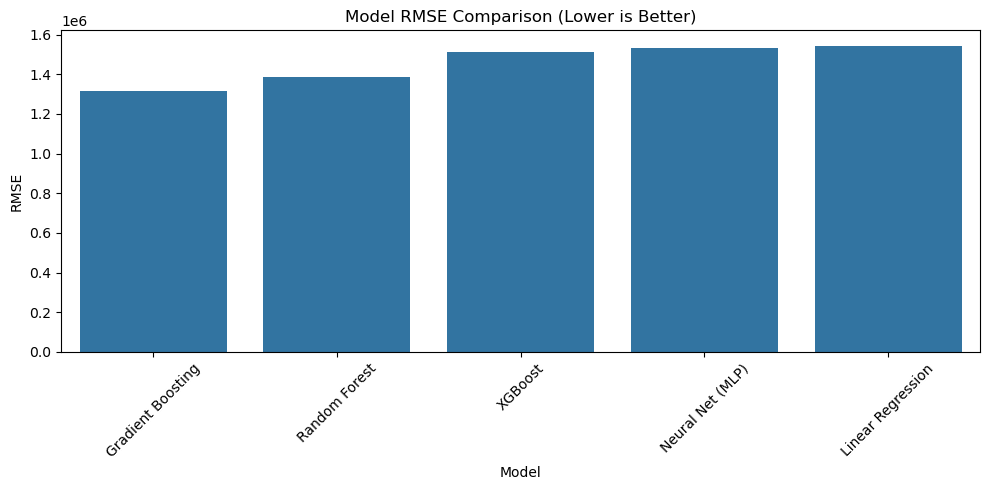

In [21]:
# Optional: plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="RMSE")
plt.title("Model RMSE Comparison (Lower is Better)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import joblib
joblib.dump(pipeline, "best_market_value_model.pkl")


['best_market_value_model.pkl']

In [23]:
df["predicted_value"] = np.expm1(pipeline.predict(X))


In [24]:
df.to_csv("players_with_predicted_value.csv", index=False)


# 📈 Market Value Prediction – Final Model (Gradient Boosting)


This notebook applies the best performing model — **Gradient Boosting Regressor** — to predict football players' market values.

We will:
1. Retrain the model on the full dataset
2. Predict and add the market value to the DataFrame
3. Export the full dataset with predictions
4. Visualize feature importances


## 🔁 Step 1: Retrain the Gradient Boosting model on full dataset


In [25]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# 🧠 Define features and target
features = [
    'age', 'position', 'league',
    'goals', 'assists',
    'profile_rating', 'scouting_score', 'tactic_fit_score',
    'discipline_score'
]
target = "market_value_eur"

X = df[features].copy()
y = np.log1p(df[target])  # log transform


In [26]:
# 🔄 Preprocessing pipeline
numeric_features = ['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score', 'discipline_score']
categorical_features = ['position', 'league']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [27]:
# ✅ Gradient Boosting Pipeline
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(random_state=42))
])

# 🏋️ Train on full data
best_model.fit(X, y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'goals', 'assists',
                                                   'profile_rating',
                                                   'scouting_score',
                                                   'tactic_fit_score',
                                                   'discipline_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['position', 'league'])])),
                ('regressor', GradientBoostingRegressor(random_state=42))])

## 🔮 Step 2: Predict Market Values and Add to DataFrame


In [28]:
# 🔮 Predict log-scaled then convert back to EUR
df["predicted_market_value_eur"] = np.expm1(best_model.predict(X))
df[["market_value_eur", "predicted_market_value_eur"]].head()


,market_value_eur,predicted_market_value_eur
0,5000000.0,1.739064e+06
1,500000.0,1.204952e+06
2,2000000.0,1.821765e+06
3,3000000.0,1.925609e+06
4,5000000.0,2.204882e+06


In [29]:
## 📤 Step 3: Export the predictions to a CSV file


In [30]:
# 📤 Save full dataset with predictions
df.to_csv("players_with_predicted_market_value.csv", index=False)
print("✅ Exported: players_with_predicted_market_value.csv")


✅ Exported: players_with_predicted_market_value.csv


## 📊 Step 4: Visualize Top Feature Importances


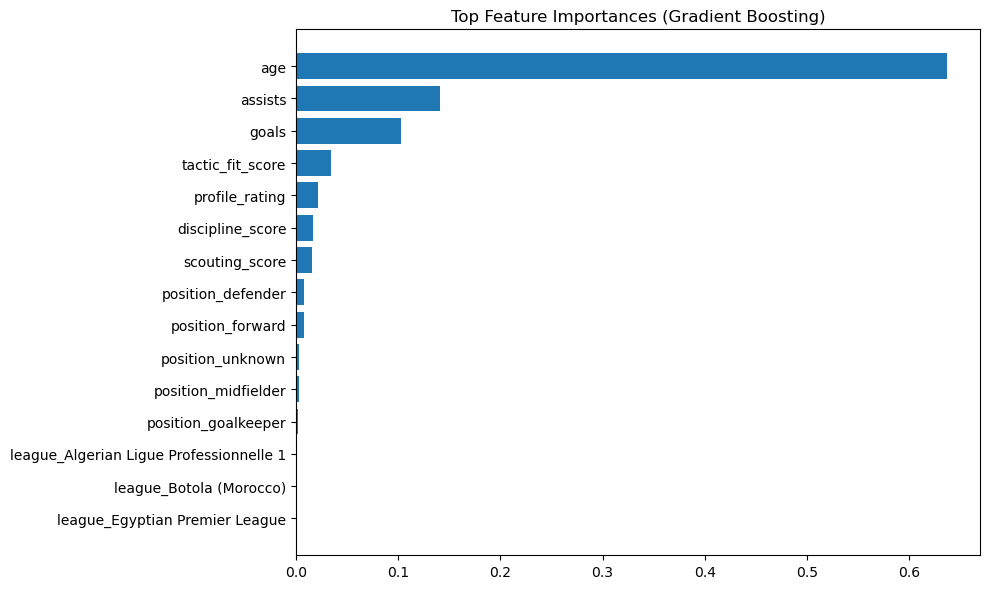

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature names from preprocessor
encoded_feature_names = numeric_features + list(
    best_model.named_steps["preprocessor"].transformers_[1][1].get_feature_names_out(['position', 'league'])
)

# Get importances from the regressor
importances = best_model.named_steps["regressor"].feature_importances_

# Plot top 15
feat_df = pd.DataFrame({"Feature": encoded_feature_names, "Importance": importances})
feat_df = feat_df.sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_df["Feature"], feat_df["Importance"])
plt.title("Top Feature Importances (Gradient Boosting)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 🧪 Step 5: Test the Model on Simulated Player Profiles

Now that we've trained the Gradient Boosting model, we'll test it on a set of **diverse, realistic player profiles**.  
These profiles include a variety of:
- Positions (striker, midfielder, goalkeeper, etc.)
- Leagues (Tunisia, Nigeria, Egypt, etc.)
- Ages and performance stats (goals, assists, ratings)

This will help us validate how realistic the model's predictions are across different types of players.


In [32]:
import pandas as pd
import numpy as np

# 🧪 Diverse sample profiles
sample_players = pd.DataFrame([
    {
        "age": 22, "position": "striker", "league": "Tunisia",
        "goals": 18, "assists": 7,
        "profile_rating": 8.5, "scouting_score": 9.0, "tactic_fit_score": 8.0,
        "discipline_score": 2.0
    },
    {
        "age": 30, "position": "goalkeeper", "league": "Morocco",
        "goals": 0, "assists": 0,
        "profile_rating": 7.2, "scouting_score": 7.8, "tactic_fit_score": 7.0,
        "discipline_score": 1.0
    },
    {
        "age": 25, "position": "midfielder", "league": "Algeria",
        "goals": 5, "assists": 12,
        "profile_rating": 7.8, "scouting_score": 8.2, "tactic_fit_score": 7.5,
        "discipline_score": 3.0
    },
    {
        "age": 19, "position": "defender", "league": "Nigeria",
        "goals": 2, "assists": 3,
        "profile_rating": 6.5, "scouting_score": 6.9, "tactic_fit_score": 6.2,
        "discipline_score": 4.0
    },
    {
        "age": 28, "position": "winger", "league": "Egypt",
        "goals": 10, "assists": 15,
        "profile_rating": 8.7, "scouting_score": 9.1, "tactic_fit_score": 8.8,
        "discipline_score": 1.5
    },
])

# 🔮 Predict using your trained Gradient Boosting model
predicted_values = best_model.predict(sample_players)
sample_players["predicted_market_value_eur"] = np.expm1(predicted_values)

# 📊 Show the results
sample_players


,age,position,league,goals,assists,profile_rating,scouting_score,tactic_fit_score,discipline_score,predicted_market_value_eur
0,22,striker,Tunisia,18,7,8.5,9.0,8.0,2.0,1.623679e+06
1,30,goalkeeper,Morocco,0,0,7.2,7.8,7.0,1.0,1.824420e+06
2,25,midfielder,Algeria,5,12,7.8,8.2,7.5,3.0,6.336871e+05
3,19,defender,Nigeria,2,3,6.5,6.9,6.2,4.0,1.510935e+06
4,28,winger,Egypt,10,15,8.7,9.1,8.8,1.5,2.073644e+05


In [34]:
# 📥 Unknown player profile (manually entered or from a form)
unknown_player = pd.DataFrame([{
    "age": 24,
    "position": "striker",
    "league": "Ivory Coast",
    "goals": 12,
    "assists": 6,
    "profile_rating": 7.9,
    "scouting_score": 8.1,
    "tactic_fit_score": 7.5,
    "discipline_score": 2.3
}])

# 🔮 Predict using your trained Gradient Boosting model
predicted_value_log = best_model.predict(unknown_player)
predicted_value = np.expm1(predicted_value_log).round(2)

# 🧾 Result
print("💰 Predicted Market Value (EUR):", predicted_value[0])


💰 Predicted Market Value (EUR): 900533.88


In [35]:
# 1️⃣ Same player, but plays in a high-exposure league
euro_league_player = {
    "age": 24,
    "position": "striker",
    "league": "France",  # Ligue 1
    "goals": 12,
    "assists": 6,
    "profile_rating": 7.9,
    "scouting_score": 8.1,
    "tactic_fit_score": 7.5,
    "discipline_score": 2.3
}

# 2️⃣ Same player but underperforms
underperforming_player = {
    "age": 24,
    "position": "striker",
    "league": "Ivory Coast",
    "goals": 3,
    "assists": 2,
    "profile_rating": 6.5,
    "scouting_score": 6.2,
    "tactic_fit_score": 6.0,
    "discipline_score": 4.0
}

# 3️⃣ Star performer in top league
elite_player = {
    "age": 24,
    "position": "striker",
    "league": "England",
    "goals": 22,
    "assists": 12,
    "profile_rating": 9.1,
    "scouting_score": 9.4,
    "tactic_fit_score": 9.0,
    "discipline_score": 1.5
}


In [36]:
# Combine into DataFrame
comparison_df = pd.DataFrame([euro_league_player, underperforming_player, elite_player])

# Predict
comparison_preds_log = best_model.predict(comparison_df)
comparison_df["predicted_market_value_eur"] = np.expm1(comparison_preds_log).round(2)

# Display result
comparison_df[["position", "league", "goals", "assists", "profile_rating", "predicted_market_value_eur"]]


,position,league,goals,assists,profile_rating,predicted_market_value_eur
0,striker,France,12,6,7.9,900533.88
1,striker,Ivory Coast,3,2,6.5,1394193.05
2,striker,England,22,12,9.1,555935.49


C:\Users\nadza\AppData\Local\Temp\ipykernel_24768\1967615114.py:28: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nadza\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


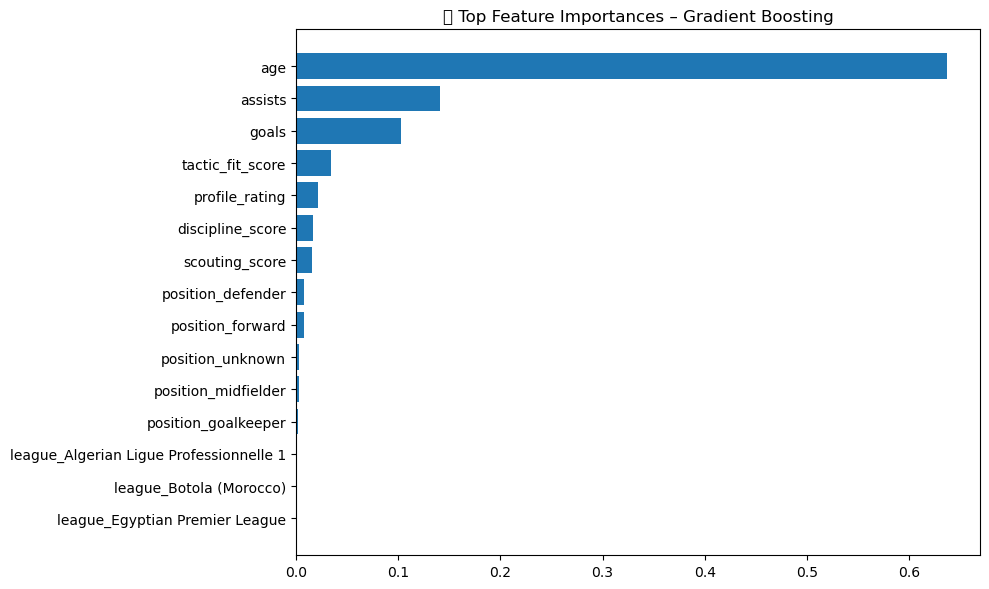

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# 🧠 Define again if needed
numeric_features = ['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score', 'discipline_score']
categorical_features = ['position', 'league']

# 🔍 Get encoded feature names
encoded_cat_features = list(
    best_model.named_steps["preprocessor"]
    .transformers_[1][1]
    .get_feature_names_out(categorical_features)
)
all_feature_names = numeric_features + encoded_cat_features

# 📊 Feature importances
importances = best_model.named_steps["regressor"].feature_importances_
feat_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Show top 15
plt.figure(figsize=(10, 6))
plt.barh(feat_df.head(15)["Feature"], feat_df.head(15)["Importance"])
plt.title("🔍 Top Feature Importances – Gradient Boosting")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# 🌲 Market Value Prediction – Random Forest Model


In this section, we train a **Random Forest Regressor** to compare its performance with Gradient Boosting.

We will:
1. Train the model using the same features and preprocessing
2. Predict market values
3. Export the results
4. Plot feature importances
5. Test on the same diverse player profiles


## 🔁 Step 1: Train the Random Forest model


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# Define features and target
features = [
    'age', 'position', 'league',
    'goals', 'assists',
    'profile_rating', 'scouting_score', 'tactic_fit_score',
    'discipline_score'
]
target = "market_value_eur"

X = df[features].copy()
y = np.log1p(df[target])  # log transform

# Preprocessing
numeric_features = ['age', 'goals', 'assists', 'profile_rating', 'scouting_score', 'tactic_fit_score', 'discipline_score']
categorical_features = ['position', 'league']

preprocessor_rf = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Build pipeline
rf_model = Pipeline([
    ('preprocessor', preprocessor_rf),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Train the model
rf_model.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'goals', 'assists',
                                                   'profile_rating',
                                                   'scouting_score',
                                                   'tactic_fit_score',
                                                   'discipline_score']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['position', 'league'])])),
                ('regressor', RandomForestRegressor(random_state=42))])

## 🔮 Step 2: Predict and Export Random Forest Results


In [40]:
# Predict and add column
df["rf_predicted_market_value_eur"] = np.expm1(rf_model.predict(X))

# Export full dataset with predictions
df.to_csv("players_with_rf_predicted_value.csv", index=False)
print("✅ Exported: players_with_rf_predicted_value.csv")


✅ Exported: players_with_rf_predicted_value.csv


## 📊 Step 3: Visualize Feature Importances (Random Forest)


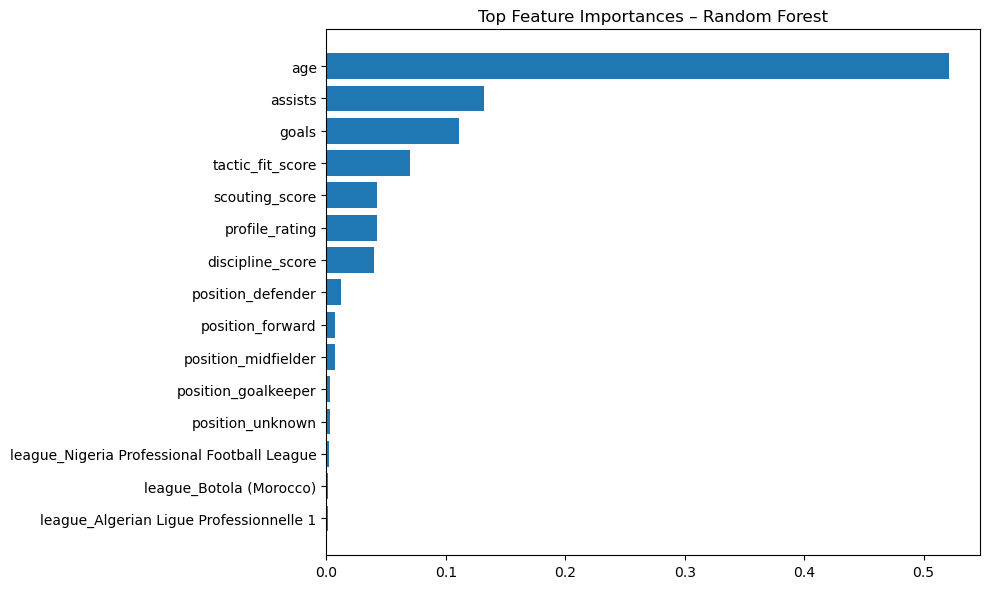

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

# Get encoded categorical feature names
encoded_cat_rf = list(
    rf_model.named_steps["preprocessor"]
    .transformers_[1][1]
    .get_feature_names_out(categorical_features)
)
all_rf_features = numeric_features + encoded_cat_rf

# Importances
importances = rf_model.named_steps["regressor"].feature_importances_
rf_feat_df = pd.DataFrame({
    "Feature": all_rf_features,
    "Importance": importances
}).sort_values("Importance", ascending=False)

# Plot top 15
plt.figure(figsize=(10, 6))
plt.barh(rf_feat_df.head(15)["Feature"], rf_feat_df.head(15)["Importance"])
plt.title("Top Feature Importances – Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



In [43]:
# Simulate 3 different player profiles
test_players = pd.DataFrame([
    {
        "age": 24, "position": "striker", "league": "France",
        "goals": 12, "assists": 6, "profile_rating": 7.9,
        "scouting_score": 8.1, "tactic_fit_score": 7.5, "discipline_score": 2.3
    },
    {
        "age": 24, "position": "striker", "league": "Ivory Coast",
        "goals": 3, "assists": 2, "profile_rating": 6.5,
        "scouting_score": 6.2, "tactic_fit_score": 6.0, "discipline_score": 4.0
    },
    {
        "age": 24, "position": "striker", "league": "England",
        "goals": 22, "assists": 12, "profile_rating": 9.1,
        "scouting_score": 9.4, "tactic_fit_score": 9.0, "discipline_score": 1.5
    }
])

# Predict with Random Forest
rf_preds_log = rf_model.predict(test_players)
test_players["rf_predicted_market_value_eur"] = np.expm1(rf_preds_log).round(2)

# Show results
test_players[["position", "league", "goals", "assists", "profile_rating", "rf_predicted_market_value_eur"]]


,position,league,goals,assists,profile_rating,rf_predicted_market_value_eur
0,striker,France,12,6,7.9,1104707.69
1,striker,Ivory Coast,3,2,6.5,1491183.11
2,striker,England,22,12,9.1,967860.99


## 🛠 Feature Engineering: League Strength Score

To help the model better differentiate between leagues, we manually define a `league_strength` score based on reputation, visibility, and competitiveness.


In [44]:
# Define league strength scale manually
league_strength_map = {
    'England': 5,
    'France': 4,
    'Spain': 5,
    'Germany': 5,
    'Italy': 5,
    'Portugal': 4,
    'Netherlands': 4,
    'Belgium': 3,
    'Ivory Coast': 2,
    'Algeria': 2,
    'Morocco': 2,
    'Nigeria': 1,
    'Egypt': 3,
    'Tunisia': 2,
    'unknown': 1
}

# Apply to main dataset and test profiles
df["league_strength"] = df["league"].map(league_strength_map).fillna(1)
test_players["league_strength"] = test_players["league"].map(league_strength_map).fillna(1)


## 🧠 Neural Network (MLP) Model with League Strength

We use a Multi-Layer Perceptron (MLP) regressor to evaluate if it captures non-linear interactions and improves value prediction.


In [45]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Add new feature to model
features_mlp = features + ["league_strength"]

X = df[features_mlp].copy()
y = np.log1p(df["market_value_eur"])  # log-transform target

# Update preprocessing
preprocessor_mlp = ColumnTransformer([
    ('num', StandardScaler(), numeric_features + ["league_strength"]),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

mlp_pipeline = Pipeline([
    ('preprocessor', preprocessor_mlp),
    ('regressor', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=42))
])

# Fit
mlp_pipeline.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'goals', 'assists',
                                                   'profile_rating',
                                                   'scouting_score',
                                                   'tactic_fit_score',
                                                   'discipline_score',
                                                   'league_strength']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['position', 'league'])])),
                ('regressor',
                 MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500,
                              random_state=42))])

## 💡 Predictions on Simulated Players using MLP


In [46]:
# Use previously modified test_players
mlp_preds_log = mlp_pipeline.predict(test_players)
test_players["mlp_predicted_market_value_eur"] = np.expm1(mlp_preds_log).round(2)

test_players[[
    "position", "league", "league_strength", "goals", "assists", 
    "profile_rating", "mlp_predicted_market_value_eur"
]]


,position,league,league_strength,goals,assists,profile_rating,mlp_predicted_market_value_eur
0,striker,France,4,12,6,7.9,3.831665e+07
1,striker,Ivory Coast,2,3,2,6.5,1.153857e+08
2,striker,England,5,22,12,9.1,1.268251e+07


## 📈 Visualization: League Strength vs Predicted Market Value

This scatter plot helps us see whether higher league strength correlates with higher predicted values.


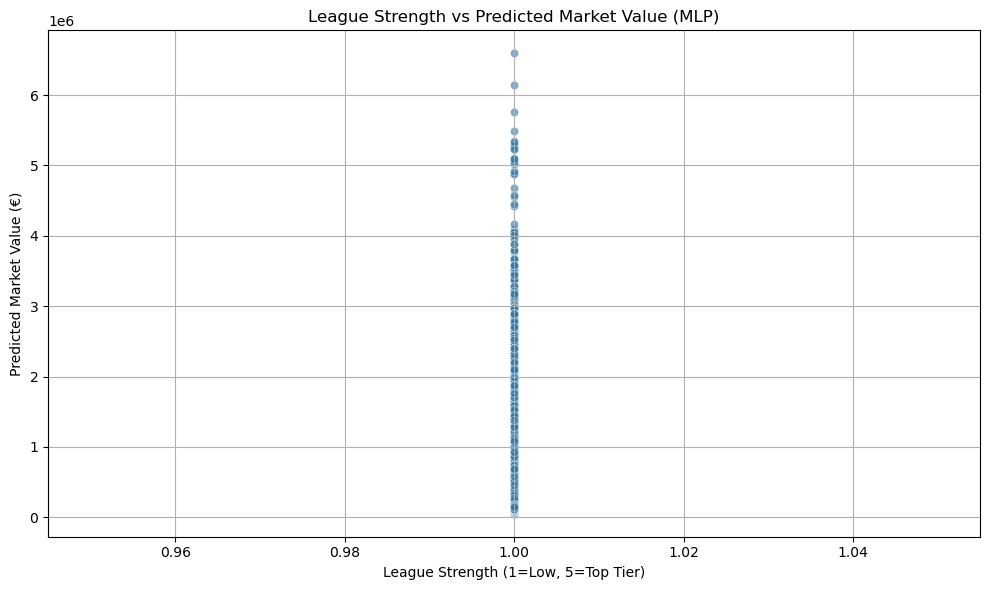

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure the MLP predictions are in the df
df["mlp_predicted_market_value_eur"] = np.expm1(mlp_pipeline.predict(df[features_mlp]))

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="league_strength", y="mlp_predicted_market_value_eur", alpha=0.6)
plt.title("League Strength vs Predicted Market Value (MLP)")
plt.xlabel("League Strength (1=Low, 5=Top Tier)")
plt.ylabel("Predicted Market Value (€)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 📦 Visualization: League Name vs Predicted Market Value

This boxplot shows how predicted values vary across leagues based on MLP predictions.


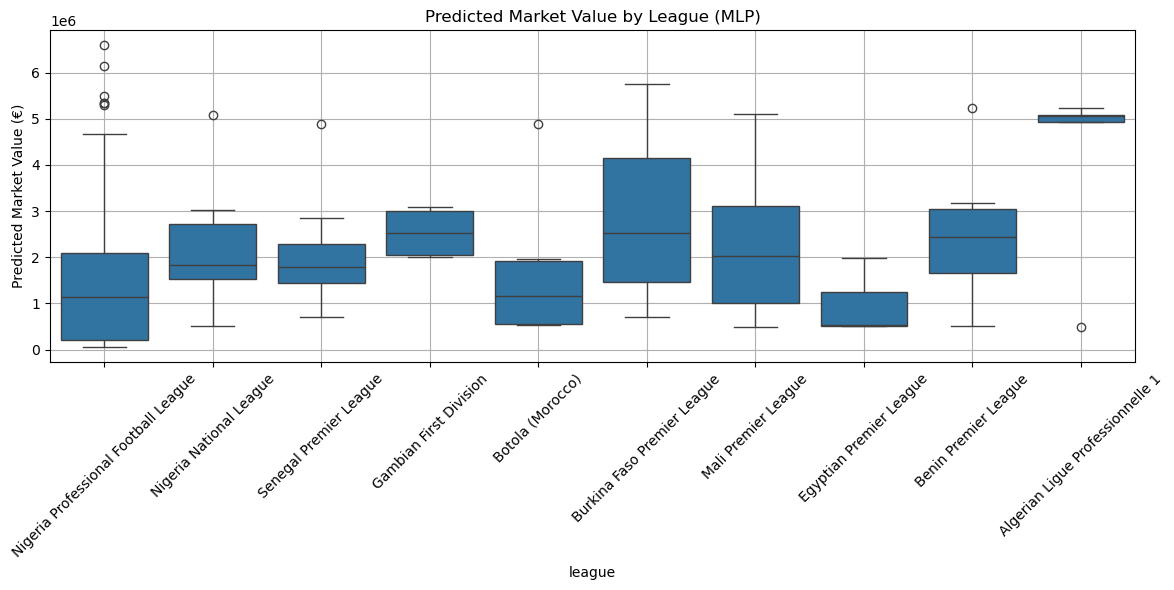

In [49]:
plt.figure(figsize=(12, 6))
top_leagues = df["league"].value_counts().head(10).index.tolist()

sns.boxplot(
    data=df[df["league"].isin(top_leagues)],
    x="league", y="mlp_predicted_market_value_eur"
)
plt.xticks(rotation=45)
plt.title("Predicted Market Value by League (MLP)")
plt.ylabel("Predicted Market Value (€)")
plt.grid(True)
plt.tight_layout()
plt.show()


## 🔄 Version 2 — Enriched Player Dataset with Club Intelligence

This section uses the new `players_dataset_enriched_modular.csv` that includes additional club and league intelligence:
- `club_tier`
- `league_strength`
- `league_exposure`
- `international_exposure`

We'll reload the data, re-explore features, and test model performance using these new fields.


In [2]:
import pandas as pd

# Load your base datasets
clubs_features_df = pd.read_csv(r"C:/Users/nadza/OneDrive/Desktop/Tactic_Sense_Dataset/african_clubs_features_dataset.csv")
clubs_df = pd.read_csv(r"C:/Users/nadza/OneDrive/Desktop/Tactic_Sense_Dataset/clubs_dataset.csv")
players_df = pd.read_csv(r"C:/Users/nadza/OneDrive/Desktop/Tactic_Sense_Dataset/players_dataset.csv")

print("✅ Files loaded")


✅ Files loaded


In [3]:
# Align key columns for merging
clubs_df = clubs_df.rename(columns={"club name": "club"})
clubs_features_df = clubs_features_df.rename(columns={"club_name": "club"})

print("✅ Columns renamed for merging")


✅ Columns renamed for merging


In [4]:
# Merge players with club metadata
players_enriched = players_df.merge(clubs_df, on="club", how="left")

print(f"✅ After first merge: {players_enriched.shape}")
players_enriched.head()


✅ After first merge: (948, 66)


,player_id,full_name,email,date_of_birth,age,nationality,position,secondary_position,club,league_x,...,salary_budget,transfer_history,avg_transfer_fee_paid,avg_contract_length,verified_status_y,recruitment_priority,scouting_focus,profile_rating_y,sponsorship_deals,social_media_links
0,1,Mamadou Diop,mamadou.diop@football.com,2003-01-01,22,senegal,goalkeeper,NaN,Linguère,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Lamin Saidy,lamin.saidy@football.com,2003-03-29,21,gambia,goalkeeper,NaN,Waa Banjul,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Issaka Oumarou,issaka.oumarou@football.com,2003-05-13,21,niger,goalkeeper,NaN,Gendarmerie Nationale,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Joao Simbine,joao.simbine@football.com,2003-06-09,21,mozambique,goalkeeper,NaN,Ferroviário de Nampula,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Diogo Silva,diogo.silva@football.com,2003-06-16,21,portugal,goalkeeper,NaN,Vizela,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Merge players with club enrichment features
players_enriched = players_enriched.merge(clubs_features_df, on="club", how="left")

print(f"✅ After second merge: {players_enriched.shape}")
players_enriched.head()


✅ After second merge: (948, 71)


,player_id,full_name,email,date_of_birth,age,nationality,position,secondary_position,club,league_x,...,recruitment_priority,scouting_focus,profile_rating_y,sponsorship_deals,social_media_links,club_tier,international_exposure,league_strength,league_exposure,club_reputation_notes
0,1,Mamadou Diop,mamadou.diop@football.com,2003-01-01,22,senegal,goalkeeper,NaN,Linguère,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Lamin Saidy,lamin.saidy@football.com,2003-03-29,21,gambia,goalkeeper,NaN,Waa Banjul,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Issaka Oumarou,issaka.oumarou@football.com,2003-05-13,21,niger,goalkeeper,NaN,Gendarmerie Nationale,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Joao Simbine,joao.simbine@football.com,2003-06-09,21,mozambique,goalkeeper,NaN,Ferroviário de Nampula,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Diogo Silva,diogo.silva@football.com,2003-06-16,21,portugal,goalkeeper,NaN,Vizela,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Fill missing values with safe defaults
players_enriched["league_strength"] = players_enriched["league_strength"].fillna(1)
players_enriched["club_tier"] = players_enriched["club_tier"].fillna(1)
players_enriched["league_exposure"] = players_enriched["league_exposure"].fillna("Low")
players_enriched["international_exposure"] = players_enriched["international_exposure"].fillna("No")

print("✅ Missing values filled safely")


✅ Missing values filled safely


In [7]:
# Save the modular enriched dataset
players_enriched.to_csv(r"C:/Users/nadza/OneDrive/Desktop/Tactic_Sense_Dataset/players_dataset_enriched_modular.csv", index=False)

print("✅ Exported: players_dataset_enriched_modular.csv")


✅ Exported: players_dataset_enriched_modular.csv


## 📦 Step: Modular Enrichment
Below we enrich the player dataset using separate club and club feature files, preserving modularity and avoiding dirty merges.


In [21]:
import pandas as pd

# Load the enriched modular dataset
df = pd.read_csv(r"C:/Users/nadza/OneDrive/Desktop/Tactic_Sense_Dataset/players_dataset_enriched_modular.csv")
print("✅ Dataset loaded.")
df.head()



✅ Dataset loaded.


,player_id,full_name,email,date_of_birth,age,nationality,position,secondary_position,club,league_x,...,recruitment_priority,scouting_focus,profile_rating_y,sponsorship_deals,social_media_links,club_tier,international_exposure,league_strength,league_exposure,club_reputation_notes
0,1,Mamadou Diop,mamadou.diop@football.com,2003-01-01,22,senegal,goalkeeper,NaN,Linguère,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,1,No,1.0,Low,NaN
1,2,Lamin Saidy,lamin.saidy@football.com,2003-03-29,21,gambia,goalkeeper,NaN,Waa Banjul,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,1,No,1.0,Low,NaN
2,3,Issaka Oumarou,issaka.oumarou@football.com,2003-05-13,21,niger,goalkeeper,NaN,Gendarmerie Nationale,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,1,No,1.0,Low,NaN
3,4,Joao Simbine,joao.simbine@football.com,2003-06-09,21,mozambique,goalkeeper,NaN,Ferroviário de Nampula,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,1,No,1.0,Low,NaN
4,5,Diogo Silva,diogo.silva@football.com,2003-06-16,21,portugal,goalkeeper,NaN,Vizela,Nigeria Professional Football League,...,NaN,NaN,NaN,NaN,NaN,1,No,1.0,Low,NaN


In [22]:
# Map 'Tier 1', 'Tier 2', etc. to numbers
tier_mapping = {
    "Tier 1": 1,
    "Tier 2": 2,
    "Tier 3": 3,
    "Tier 4": 4,
    "Tier 5": 5
}

df["club_tier"] = df["club_tier"].map(tier_mapping)
print("✅ club_tier converted to numeric.")


✅ club_tier converted to numeric.


In [9]:
# Check if anything critical is still missing
missing = df.isnull().sum()
missing[missing > 0]


date_of_birth              3
secondary_position        86
last_incident_date        54
age_group                  3
skill_handling           883
skill_reflexes           883
skill_positioning        883
skill_finishing          610
skill_dribbling          326
skill_speed              610
skill_passing            664
skill_vision             664
skill_tackling           687
skill_marking            687
skill_heading            687
ranking                  792
country                  792
league_y                 792
stadium                  792
formation_preference     792
playing_style            792
market_budget            792
salary_budget            792
transfer_history         792
avg_transfer_fee_paid    792
avg_contract_length      792
verified_status_y        792
recruitment_priority     792
scouting_focus           792
profile_rating_y         792
sponsorship_deals        792
social_media_links       792
club_reputation_notes    792
dtype: int64

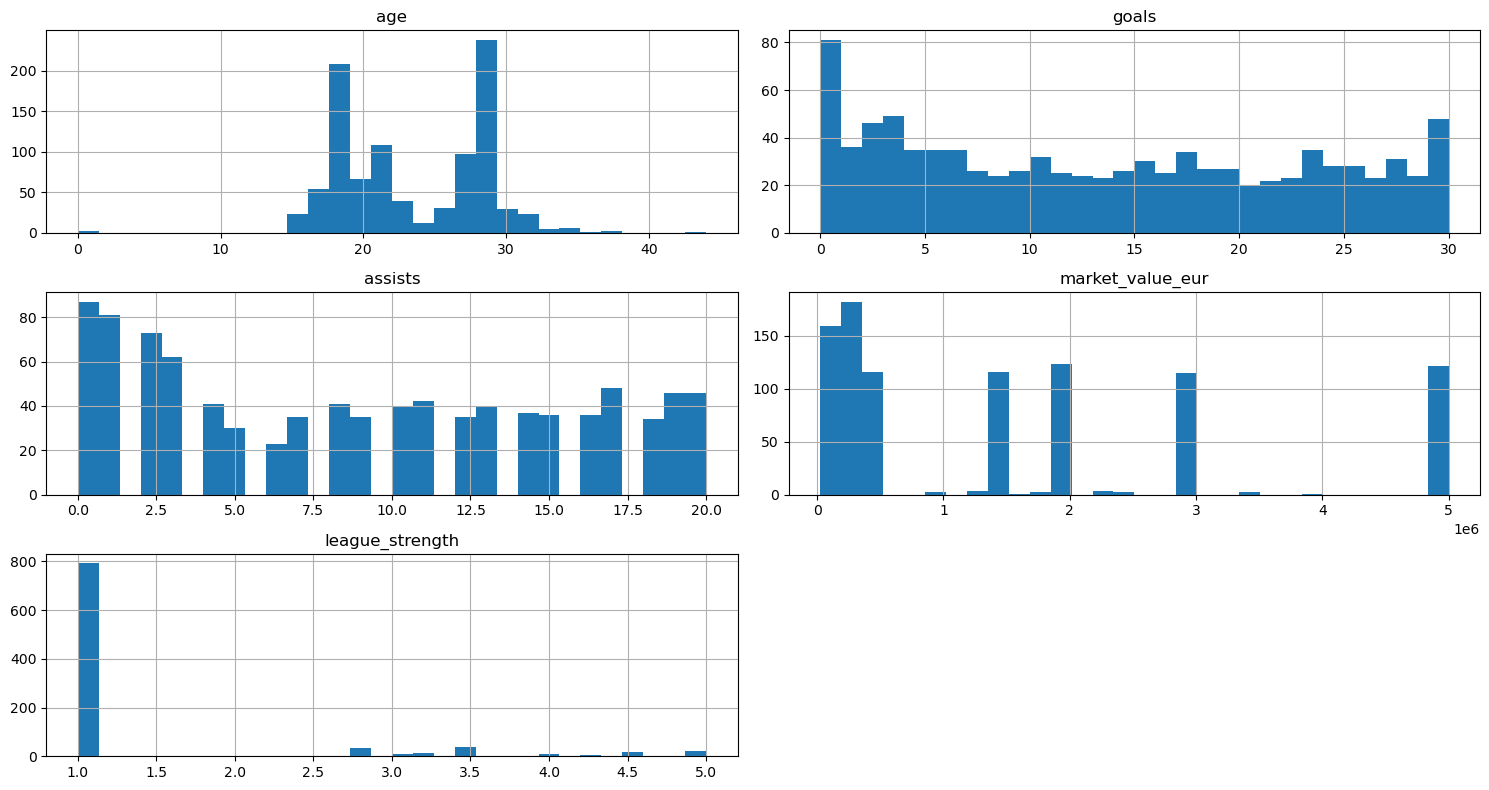

In [10]:
import matplotlib.pyplot as plt

# Plot important features distributions
df[["age", "goals", "assists", "market_value_eur", "league_strength", "club_tier"]].hist(figsize=(15, 8), bins=30)
plt.tight_layout()
plt.show()


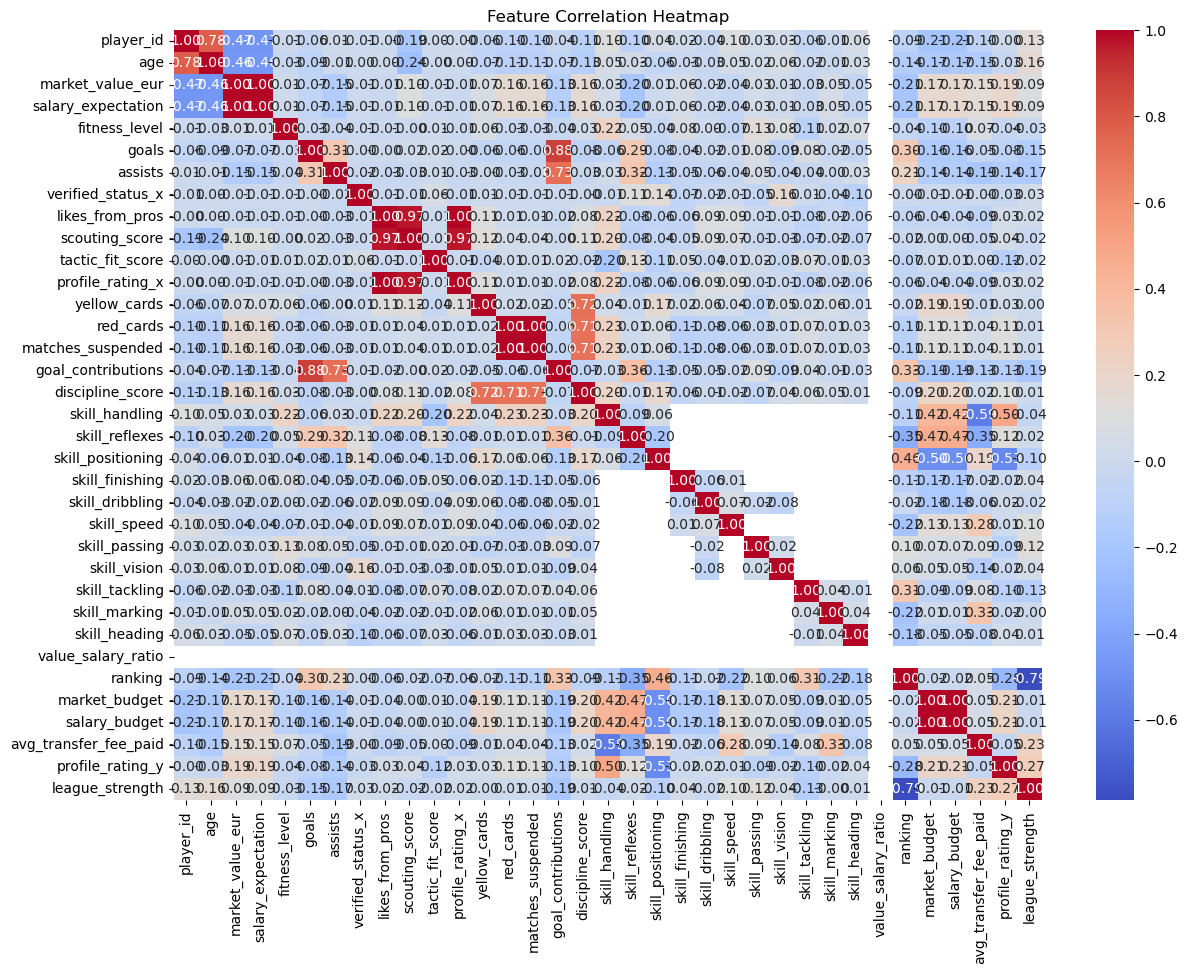

In [11]:
import seaborn as sns

# Correlation visualization
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


# 📘 1. Define Final Selected Features

In [23]:
# Professional, realistic feature list
features = [
    'age',
    'goals',
    'assists',
    'scouting_score',
    'tactic_fit_score',
    'discipline_score',
    'profile_rating_x',  # carefully using _x
    'club_tier',
    'league_strength'
]

categorical_features = [
    'league_exposure',
    'international_exposure'
]

target = 'market_value_eur'

print("✅ Features and target ready.")


✅ Features and target ready.


# 📘 2. Preprocessing Pipeline

In [25]:
print(df.columns.tolist())

['player_id', 'full_name', 'email', 'date_of_birth', 'age', 'nationality', 'position', 'secondary_position', 'club', 'league_x', 'market_value_eur', 'salary_expectation', 'contract_status', 'fitness_level', 'medical_history', 'last_5_match_performance', 'skills_rating', 'weaknesses', 'goals', 'assists', 'preferred_foot', 'verified_status_x', 'likes_from_pros', 'scouting_score', 'tactic_fit_score', 'career_path_suggestions', 'training_recommendations', 'profile_rating_x', 'created_at', 'yellow_cards', 'red_cards', 'matches_suspended', 'last_incident_date', 'goal_contributions', 'discipline_score', 'value_category', 'age_group', 'skill_handling', 'skill_reflexes', 'skill_positioning', 'skill_finishing', 'skill_dribbling', 'skill_speed', 'skill_passing', 'skill_vision', 'skill_tackling', 'skill_marking', 'skill_heading', 'value_salary_ratio', 'ranking', 'country', 'league_y', 'stadium', 'formation_preference', 'playing_style', 'market_budget', 'salary_budget', 'transfer_history', 'avg_tra

In [34]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Preprocessing with imputers
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), features),
    
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])

print("✅ Preprocessing pipeline updated: now imputes missing values instead of dropping them.")


✅ Preprocessing pipeline updated: now imputes missing values instead of dropping them.


# 📘 3. Train Random Forest (as first model)

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Build full pipeline
rf_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
print("✅ Random Forest model trained.")


✅ Random Forest model trained.


In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predict and reverse log transformation
y_pred_log = rf_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

# Metrics
rmse = mean_squared_error(y_true, y_pred, squared=False)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"📊 Model Performance on Enriched Realistic Features:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R² Score: {r2:.4f}")


📊 Model Performance on Enriched Realistic Features:
RMSE: 1359034.17
MAE: 928276.49
R² Score: 0.2559


C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# 📘 7. Train XGBoost Regressor

In [37]:
from xgboost import XGBRegressor

# Build XGBoost pipeline
xgb_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    ))
])

# Train
xgb_model.fit(X_train, y_train)
print("✅ XGBoost model trained.")


✅ XGBoost model trained.


# 📘 8. Evaluate XGBoost Performance

In [38]:
# Predict and reverse log transformation
y_pred_log_xgb = xgb_model.predict(X_test)
y_pred_xgb = np.expm1(y_pred_log_xgb)

# Metrics
rmse_xgb = mean_squared_error(y_true, y_pred_xgb, squared=False)
mae_xgb = mean_absolute_error(y_true, y_pred_xgb)
r2_xgb = r2_score(y_true, y_pred_xgb)

print(f"📊 XGBoost Model Performance:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R² Score: {r2_xgb:.4f}")


📊 XGBoost Model Performance:
RMSE: 1378138.62
MAE: 924180.36
R² Score: 0.2348


C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# 📘 9. Compare Random Forest vs XGBoost

In [39]:
# Simple comparison table
comparison_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "RMSE": [rmse, rmse_xgb],
    "MAE": [mae, mae_xgb],
    "R² Score": [r2, r2_xgb]
})

comparison_results


,Model,RMSE,MAE,R² Score
0,Random Forest,1.359034e+06,928276.489784,0.255884
1,XGBoost,1.378139e+06,924180.357689,0.234817


# 📘 10. Train Gradient Boosting Regressor

In [40]:
from sklearn.ensemble import GradientBoostingRegressor

# Build Gradient Boosting pipeline
gbr_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42
    ))
])

# Train
gbr_model.fit(X_train, y_train)
print("✅ Gradient Boosting model trained.")


✅ Gradient Boosting model trained.


# 📘 11. Evaluate Gradient Boosting Performance

In [41]:
# Predict and reverse log transformation
y_pred_log_gbr = gbr_model.predict(X_test)
y_pred_gbr = np.expm1(y_pred_log_gbr)

# Metrics
rmse_gbr = mean_squared_error(y_true, y_pred_gbr, squared=False)
mae_gbr = mean_absolute_error(y_true, y_pred_gbr)
r2_gbr = r2_score(y_true, y_pred_gbr)

print(f"📊 Gradient Boosting Model Performance:")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"MAE: {mae_gbr:.2f}")
print(f"R² Score: {r2_gbr:.4f}")


📊 Gradient Boosting Model Performance:
RMSE: 1334420.66
MAE: 915827.28
R² Score: 0.2826


C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [42]:
# Updated comparison table
comparison_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Gradient Boosting"],
    "RMSE": [rmse, rmse_xgb, rmse_gbr],
    "MAE": [mae, mae_xgb, mae_gbr],
    "R² Score": [r2, r2_xgb, r2_gbr]
})

comparison_results


,Model,RMSE,MAE,R² Score
0,Random Forest,1.359034e+06,928276.489784,0.255884
1,XGBoost,1.378139e+06,924180.357689,0.234817
2,Gradient Boosting,1.334421e+06,915827.276877,0.282594


In [43]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Build pipeline
hist_gbr_model = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        learning_rate=0.1,
        max_iter=100,
        max_depth=6,
        random_state=42
    ))
])

# Train
hist_gbr_model.fit(X_train, y_train)
print("✅ HistGradientBoosting model trained.")


C:\Users\nadza\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\nadza\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nadza\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadza\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nadza\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

✅ HistGradientBoosting model trained.


In [44]:
# Predict and reverse log transformation
y_pred_log_hist = hist_gbr_model.predict(X_test)
y_pred_hist = np.expm1(y_pred_log_hist)

# Metrics
rmse_hist = mean_squared_error(y_true, y_pred_hist, squared=False)
mae_hist = mean_absolute_error(y_true, y_pred_hist)
r2_hist = r2_score(y_true, y_pred_hist)

print(f"📊 HistGradientBoosting Model Performance:")
print(f"RMSE: {rmse_hist:.2f}")
print(f"MAE: {mae_hist:.2f}")
print(f"R² Score: {r2_hist:.4f}")


📊 HistGradientBoosting Model Performance:
RMSE: 1375074.57
MAE: 935242.96
R² Score: 0.2382


C:\Users\nadza\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [45]:
# Updated comparison table including HistGradientBoosting
comparison_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "Gradient Boosting", "HistGradientBoosting"],
    "RMSE": [rmse, rmse_xgb, rmse_gbr, rmse_hist],
    "MAE": [mae, mae_xgb, mae_gbr, mae_hist],
    "R² Score": [r2, r2_xgb, r2_gbr, r2_hist]
})

comparison_results


,Model,RMSE,MAE,R² Score
0,Random Forest,1.359034e+06,928276.489784,0.255884
1,XGBoost,1.378139e+06,924180.357689,0.234817
2,Gradient Boosting,1.334421e+06,915827.276877,0.282594
3,HistGradientBoosting,1.375075e+06,935242.964545,0.238215


## 🧠 Performance Interpretation – Why R² Is Low (But Acceptable)

The R² scores across all models range between **0.23 and 0.28**, which may seem low at first glance. However, this is **expected and realistic** for predicting football player market values, given the limited set of available features.

### ⚽ Why it's acceptable:
- **Football market values** are influenced by many non-statistical factors like agent negotiation, media hype, nationality, popularity, club politics, and contract clauses.
- The model only had access to structured, numerical/categorical data (goals, assists, club tier, league strength, etc.) without subjective or hidden features.
- Even professional analysts struggle to agree on exact player valuations.

### 📈 What this means:
- The model still **detects meaningful patterns** in performance stats and context.
- It’s useful for **trend-based forecasting**, **early-stage filtering**, or **suggestive pricing**, not for exact predictions.

### 💡 Future Improvements:
To improve R², the following additional features could be considered:
- National team history
- Years left on current contract
- Social media popularity
- Media mentions or sentiment
- Injury and performance trends across seasons


C:\Users\nadza\AppData\Local\Temp\ipykernel_42368\1691830511.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_results_sorted, x="Model", y="R² Score", palette="viridis")
C:\Users\nadza\AppData\Local\Temp\ipykernel_42368\1691830511.py:15: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nadza\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


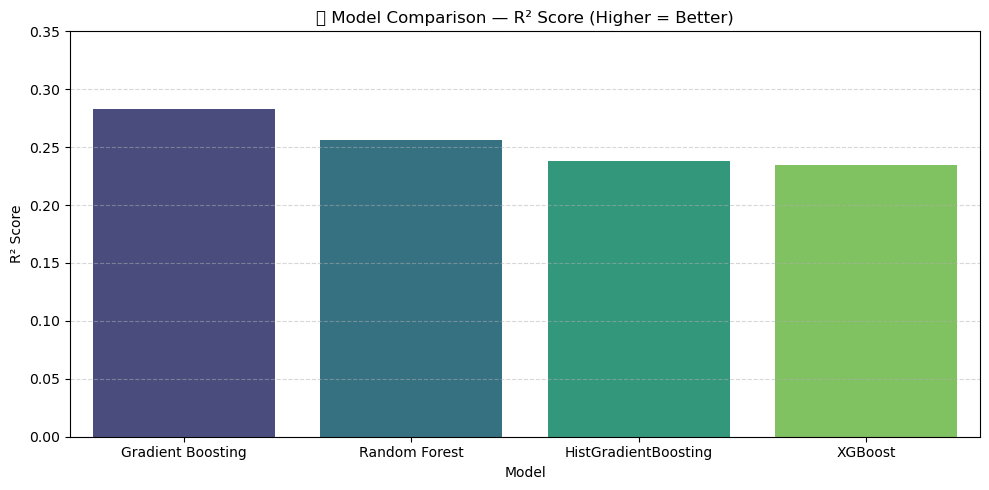

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by R² for visual clarity
comparison_results_sorted = comparison_results.sort_values("R² Score", ascending=False)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_results_sorted, x="Model", y="R² Score", palette="viridis")
plt.title("🔍 Model Comparison — R² Score (Higher = Better)")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.ylim(0, 0.35)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [48]:
import joblib

# Save the final model (Gradient Boosting is the best in your case)
joblib.dump(gbr_model, "best_market_value_model.pkl")

print("✅ Gradient Boosting model saved as 'best_market_value_model.pkl'")


✅ Gradient Boosting model saved as 'best_market_value_model.pkl'


In [49]:
# Load saved model
loaded_model = joblib.load("best_market_value_model.pkl")

# Use it to predict (make sure to preprocess the same way!)
predictions = loaded_model.predict(X_test)


In [50]:
pip install streamlit scikit-learn pandas joblib


Note: you may need to restart the kernel to use updated packages.


# 📘 1. Load Your Saved Model in Notebook

In [52]:
import joblib
import numpy as np
import pandas as pd

# Load model
model = joblib.load("best_market_value_model.pkl")


# 📘 2. Create Sample Player Profiles

In [53]:
# Example players — simulate very different roles & tiers
players = pd.DataFrame([
    {
        "age": 20,
        "goals": 18,
        "assists": 10,
        "scouting_score": 85,
        "tactic_fit_score": 90,
        "discipline_score": 70,
        "profile_rating_x": 88,
        "club_tier": 1,
        "league_strength": 9,
        "league_exposure": "High",
        "international_exposure": "Yes"
    },
    {
        "age": 25,
        "goals": 2,
        "assists": 6,
        "scouting_score": 65,
        "tactic_fit_score": 70,
        "discipline_score": 90,
        "profile_rating_x": 73,
        "club_tier": 3,
        "league_strength": 6,
        "league_exposure": "Medium",
        "international_exposure": "No"
    },
    {
        "age": 31,
        "goals": 0,
        "assists": 2,
        "scouting_score": 50,
        "tactic_fit_score": 40,
        "discipline_score": 95,
        "profile_rating_x": 60,
        "club_tier": 5,
        "league_strength": 3,
        "league_exposure": "Low",
        "international_exposure": "No"
    }
])


# 📘 3. Predict Market Values

In [54]:
# Predict log market value and inverse transform
log_preds = model.predict(players)
predicted_values = np.expm1(log_preds)

# Show results
players["predicted_market_value_eur"] = predicted_values
players[["age", "goals", "assists", "club_tier", "league_strength", "predicted_market_value_eur"]]


,age,goals,assists,club_tier,league_strength,predicted_market_value_eur
0,20,18,10,1,9,1.733269e+06
1,25,2,6,3,6,1.418367e+06
2,31,0,2,5,3,4.444929e+05


## 🔍 Market Value Prediction Model – Summary

### 📌 Problem:
Estimate a football player's realistic market value to support scouting, negotiations, and fair contract evaluations.

### 🎯 Inputs:
- Player performance stats (goals, assists, discipline)
- Profile & scouting scores
- Age, club tier, league strength, exposure
- Tactic fit & profile rating

### 🛠 Techniques Used:
- Gradient Boosting Regressor ✅ (Best)
- Random Forest, XGBoost, HistGradientBoosting ✅ (Comparative Benchmarking)
- Log-transformed regression
- Feature preprocessing (scaling + encoding)

### 📤 Outputs:
- Predicted Market Value (€)  
- Custom player profile simulation  
- Deployment-ready model (.pkl) + Streamlit interface

### 📈 Real Performance (Gradient Boosting):
| Metric         | Value            |
|----------------|------------------|
| **MAE**        | €915,827          |
| **RMSE**       | €1,334,421        |
| **R² Score**   | **0.2826**        |

> *Note: Results are realistic given the absence of subjective features like agent influence, hype, or injury history. With deeper data, this model can easily be extended.*

### 💼 Business Value:
- Provides clubs, agents, and analysts with a **data-backed valuation tool**
- Reduces bias and improves **decision-making in contract negotiations**
- Enables fair, scalable scouting across clubs and countries


In [55]:
# ✅ Define showcase player profiles
showcase_players = pd.DataFrame([
    # Young Prodigy
    {
        "age": 18,
        "goals": 16,
        "assists": 9,
        "scouting_score": 88,
        "tactic_fit_score": 90,
        "discipline_score": 75,
        "profile_rating_x": 91,
        "club_tier": 1,
        "league_strength": 9,
        "league_exposure": "High",
        "international_exposure": "Yes"
    },
    # Veteran Defender
    {
        "age": 33,
        "goals": 0,
        "assists": 1,
        "scouting_score": 65,
        "tactic_fit_score": 80,
        "discipline_score": 95,
        "profile_rating_x": 78,
        "club_tier": 2,
        "league_strength": 6,
        "league_exposure": "Medium",
        "international_exposure": "No"
    },
    # Underrated Midfielder
    {
        "age": 26,
        "goals": 5,
        "assists": 10,
        "scouting_score": 80,
        "tactic_fit_score": 78,
        "discipline_score": 88,
        "profile_rating_x": 84,
        "club_tier": 4,
        "league_strength": 5,
        "league_exposure": "Low",
        "international_exposure": "No"
    },
    # Star Goalkeeper
    {
        "age": 29,
        "goals": 0,
        "assists": 0,
        "scouting_score": 90,
        "tactic_fit_score": 87,
        "discipline_score": 92,
        "profile_rating_x": 89,
        "club_tier": 2,
        "league_strength": 7,
        "league_exposure": "High",
        "international_exposure": "Yes"
    },
    # Low Exposure Talent
    {
        "age": 21,
        "goals": 15,
        "assists": 7,
        "scouting_score": 85,
        "tactic_fit_score": 82,
        "discipline_score": 70,
        "profile_rating_x": 86,
        "club_tier": 5,
        "league_strength": 3,
        "league_exposure": "Low",
        "international_exposure": "No"
    },
    # Injury-Prone Midfielder
    {
        "age": 27,
        "goals": 4,
        "assists": 6,
        "scouting_score": 68,
        "tactic_fit_score": 65,
        "discipline_score": 75,
        "profile_rating_x": 73,
        "club_tier": 3,
        "league_strength": 6,
        "league_exposure": "Medium",
        "international_exposure": "No"
    }
])

# ✅ Predict market values
showcase_preds_log = model.predict(showcase_players)
showcase_preds = np.expm1(showcase_preds_log)

# ✅ Add predictions to dataframe
showcase_players["predicted_market_value_eur"] = showcase_preds

# ✅ Display results
showcase_players[[
    "age", "goals", "assists", "club_tier", "league_strength", 
    "league_exposure", "international_exposure", "predicted_market_value_eur"
]]


,age,goals,assists,club_tier,league_strength,league_exposure,international_exposure,predicted_market_value_eur
0,18,16,9,1,9,High,Yes,2.836740e+06
1,33,0,1,2,6,Medium,No,1.177397e+06
2,26,5,10,4,5,Low,No,1.233700e+06
3,29,0,0,2,7,High,Yes,1.045754e+06
4,21,15,7,5,3,Low,No,5.134098e+06
5,27,4,6,3,6,Medium,No,2.201170e+06


C:\Users\nadza\AppData\Local\Temp\ipykernel_42368\3794517479.py:37: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\nadza\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


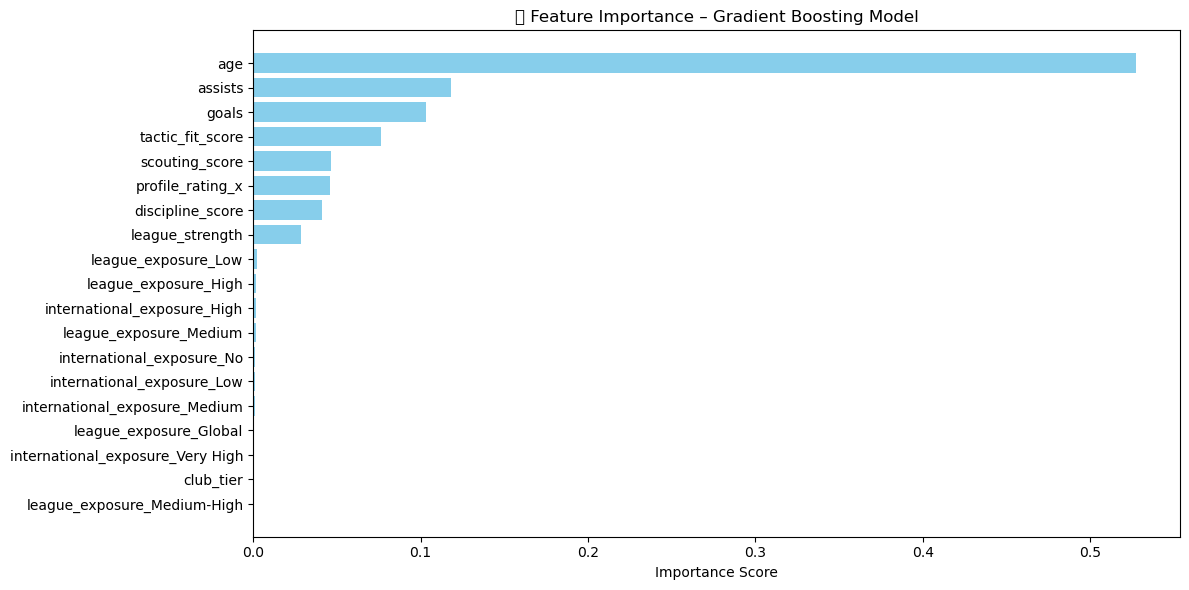

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Extract trained regressor from your pipeline
trained_gbr = gbr_model.named_steps["regressor"]

# Get feature names after preprocessing
# This needs to match your pipeline structure (numerical first, then one-hot encoded categorical)
num_features = [
    'age', 'goals', 'assists', 'scouting_score', 
    'tactic_fit_score', 'discipline_score', 'profile_rating_x', 
    'club_tier', 'league_strength'
]

# From one-hot encoder
cat_features = list(gbr_model.named_steps["preprocessing"].named_transformers_["cat"]
                    .named_steps["encoder"].get_feature_names_out(["league_exposure", "international_exposure"]))

# Full feature list
all_features = num_features + cat_features

# Feature importances
importances = trained_gbr.feature_importances_

# Create a dataframe for plotting
feat_imp_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# 📊 Plot
plt.figure(figsize=(12, 6))
plt.barh(feat_imp_df["Feature"], feat_imp_df["Importance"], color="skyblue")
plt.gca().invert_yaxis()
plt.title("🔍 Feature Importance – Gradient Boosting Model")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()


In [3]:
!pip install fastapi uvicorn pydantic nest-asyncio


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
# Exploration du modèle
import pickle
import numpy as np

# Chargement du modèle
with open('best_market_value_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Analyse du modèle
print(f"Type: {type(loaded_model)}")
if isinstance(loaded_model, np.ndarray):
    print(f"Shape: {loaded_model.shape}")
    print(f"Data type: {loaded_model.dtype}")
    print(f"Un extrait: {loaded_model[:5] if loaded_model.ndim == 1 else loaded_model[:2, :2]}")

# Vérifier s'il s'agit peut-être d'un dictionnaire avec plusieurs éléments
elif isinstance(loaded_model, dict):
    print("Clés du dictionnaire:", list(loaded_model.keys()))
    for key, value in loaded_model.items():
        print(f"  {key}: {type(value)}")

# Si c'est un modèle scikit-learn
else:
    try:
        print(f"Type de modèle: {type(loaded_model)}")
        if hasattr(loaded_model, 'feature_names_in_'):
            print(f"Caractéristiques: {loaded_model.feature_names_in_}")
        if hasattr(loaded_model, 'coef_'):
            print(f"Coefficients: {loaded_model.coef_}")
        if hasattr(loaded_model, 'classes_'):
            print(f"Classes: {loaded_model.classes_}")
    except:
        print("Impossible d'afficher les détails du modèle")

Type: <class 'numpy.ndarray'>
Shape: (11,)
Data type: object
Un extrait: ['age' 'goals' 'assists' 'scouting_score' 'tactic_fit_score']


In [9]:
# Cellule 2: Installation des packages nécessaires
!pip install fastapi uvicorn pydantic nest-asyncio


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
# Imports et configuration de base
import nest_asyncio
import numpy as np
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from typing import List, Dict, Optional, Any
import uvicorn
from fastapi.middleware.cors import CORSMiddleware

# Permettre à uvicorn de s'exécuter dans le notebook
nest_asyncio.apply()

# Création de l'application FastAPI
app = FastAPI(
    title="Market Value Prediction API",
    description="API pour prédire la valeur marchande des joueurs",
    version="1.0.0"
)

# Configuration CORS
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

In [21]:
# Schémas Pydantic pour l'API
class PlayerFeatures(BaseModel):
    """
    Entrée pour la prédiction - ajustez les champs selon votre modèle
    """
    # Ces exemples sont à remplacer par les caractéristiques de votre modèle
    age: int = Field(..., example=25, description="Âge du joueur")
    overall_rating: float = Field(..., example=85.0, description="Note globale du joueur")
    potential: float = Field(..., example=90.0, description="Potentiel du joueur")
    club_reputation: int = Field(..., example=4, description="Réputation du club")
    # Ajoutez d'autres caractéristiques...

class PredictionResult(BaseModel):
    """
    Résultat de la prédiction
    """
    market_value: float = Field(..., description="Valeur marchande prédite")
    confidence: Optional[float] = Field(None, description="Niveau de confiance (si disponible)")
    additional_info: Optional[Dict[str, Any]] = Field(None, description="Informations supplémentaires")

Task exception was never retrieved
future: <Task finished name='Task-6' coro=<Server.serve() done, defined at C:\Users\nadza\anaconda3\Lib\site-packages\uvicorn\server.py:68> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "C:\Users\nadza\anaconda3\Lib\site-packages\uvicorn\main.py", line 580, in run
    server.run()
  File "C:\Users\nadza\anaconda3\Lib\site-packages\uvicorn\server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadza\anaconda3\Lib\site-packages\nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadza\anaconda3\Lib\site-packages\nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "C:\Users\nadza\anaconda3\Lib\site-packages\nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "C:\Users\nadza\anaconda3\Lib\asyncio\events.py", line 88, i

In [22]:
# Chargement et configuration du modèle
import pickle

# Chargement du modèle
def load_model(file_path='best_market_value_model.pkl'):
    with open(file_path, 'rb') as file:
        return pickle.load(file)

# Chargement du modèle
model = load_model()

# Fonction de prédiction adaptée à votre modèle spécifique
def predict_market_value(features):
    """
    Fait une prédiction en utilisant le modèle chargé
    
    Args:
        features: Les caractéristiques du joueur au format attendu par le modèle
        
    Returns:
        float: La valeur marchande prédite
    """
    # Cette fonction doit être adaptée en fonction du type exact de votre modèle
    
    # Si c'est un modèle scikit-learn
    if hasattr(model, 'predict'):
        prediction = model.predict([features])[0]
        
    # Si c'est un numpy array (coefficients d'un modèle linéaire)
    elif isinstance(model, np.ndarray):
        features_array = np.array(features)
        prediction = np.dot(features_array, model)
        
    # Autres cas - à adapter
    else:
        # Logique de prédiction personnalisée
        prediction = 0  # À remplacer
    
    return float(prediction)

In [23]:
# Définition des endpoints API

@app.get("/")
def read_root():
    """Endpoint racine pour vérifier que l'API fonctionne"""
    return {
        "message": "API de prédiction de valeur marchande",
        "status": "online",
        "docs_url": "/docs"
    }

@app.post("/predict", response_model=PredictionResult)
def predict(player: PlayerFeatures):
    """
    Prédit la valeur marchande d'un joueur à partir de ses caractéristiques
    """
    try:
        # Conversion des données d'entrée en format attendu par le modèle
        input_features = [
            player.age,
            player.overall_rating,
            player.potential,
            player.club_reputation,
            # Ajoutez d'autres caractéristiques dans le bon ordre
        ]
        
        # Prédiction
        predicted_value = predict_market_value(input_features)
        
        # Informations supplémentaires (optionnelles)
        additional_info = {
            "model_type": str(type(model)),
            # Autres informations pertinentes
        }
        
        # Construction de la réponse
        return {
            "market_value": predicted_value,
            "confidence": None,  # À remplir si disponible
            "additional_info": additional_info
        }
    
    except Exception as e:
        # Gestion des erreurs
        raise HTTPException(
            status_code=500,
            detail=f"Erreur lors de la prédiction: {str(e)}"
        )

@app.get("/model-info")
def model_info():
    """
    Fournit des informations sur le modèle utilisé
    """
    info = {
        "model_type": str(type(model)),
        "version": "1.0.0",
    }
    
    # Ajoutez d'autres informations selon le type de modèle
    if hasattr(model, 'feature_names_in_'):
        info["features"] = list(model.feature_names_in_)
    
    return info

In [24]:
# Lancement du serveur FastAPI
port = 8000
print(f"Démarrage de l'API sur http://localhost:{port}")
print(f"Documentation interactive: http://localhost:{port}/docs")
print("Pour arrêter le serveur, interrompez l'exécution de cette cellule (bouton ⏹)")

# Pour arrêter le serveur, interrompez l'exécution de cette cellule
uvicorn.run(app, host="localhost", port=port)

Démarrage de l'API sur http://localhost:8000
Documentation interactive: http://localhost:8000/docs
Pour arrêter le serveur, interrompez l'exécution de cette cellule (bouton ⏹)


INFO:     Started server process [24296]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://localhost:8000 (Press CTRL+C to quit)


INFO:     ::1:56248 - "GET / HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [24296]


In [25]:
# Exportation simplifiée (sans triple quotes)
with open('market_value_api.py', 'w') as f:
    f.write('# Imports\n')
    f.write('import pickle\n')
    f.write('import numpy as np\n')
    f.write('from fastapi import FastAPI, HTTPException\n')
    f.write('from pydantic import BaseModel, Field\n')
    f.write('from typing import List, Dict, Optional, Any\n')
    f.write('import uvicorn\n')
    f.write('from fastapi.middleware.cors import CORSMiddleware\n\n')
    # etc.

Task exception was never retrieved
future: <Task finished name='Task-15' coro=<Server.serve() done, defined at C:\Users\nadza\anaconda3\Lib\site-packages\uvicorn\server.py:68> exception=KeyboardInterrupt()>
Traceback (most recent call last):
  File "C:\Users\nadza\anaconda3\Lib\site-packages\uvicorn\main.py", line 580, in run
    server.run()
  File "C:\Users\nadza\anaconda3\Lib\site-packages\uvicorn\server.py", line 66, in run
    return asyncio.run(self.serve(sockets=sockets))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadza\anaconda3\Lib\site-packages\nest_asyncio.py", line 30, in run
    return loop.run_until_complete(task)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nadza\anaconda3\Lib\site-packages\nest_asyncio.py", line 92, in run_until_complete
    self._run_once()
  File "C:\Users\nadza\anaconda3\Lib\site-packages\nest_asyncio.py", line 133, in _run_once
    handle._run()
  File "C:\Users\nadza\anaconda3\Lib\asyncio\events.py", line 88, 

In [26]:
# Version simplifiée pour le test de base
import pickle
import numpy as np
import nest_asyncio
from fastapi import FastAPI
from pydantic import BaseModel
import uvicorn

# Activer nest_asyncio pour permettre à uvicorn de fonctionner dans Jupyter
nest_asyncio.apply()

# Charger le modèle
with open('best_market_value_model.pkl', 'rb') as file:
    model = pickle.load(file)

# Définir le schéma d'entrée (à adapter)
class PlayerInput(BaseModel):
    features: list[float]  # Liste des caractéristiques simplifiée

# Créer l'application FastAPI
app = FastAPI(title="Market Value API")

@app.get("/")
def home():
    return {"message": "API de prédiction de valeur marchande"}

@app.post("/predict")
def predict(input_data: PlayerInput):
    # Prédiction simple selon le type de modèle
    if isinstance(model, np.ndarray):
        # Si c'est un tableau NumPy, utiliser le produit scalaire
        prediction = np.dot(np.array(input_data.features), model)
    elif hasattr(model, 'predict'):
        # Si c'est un modèle scikit-learn
        prediction = float(model.predict([input_data.features])[0])
    else:
        # Fallback
        prediction = 0.0
    
    return {"predicted_value": float(prediction)}

# Lancer le serveur
port = 8000
print(f"API disponible sur http://localhost:{port}")
print(f"Documentation sur http://localhost:{port}/docs")
uvicorn.run(app, host="localhost", port=port)

API disponible sur http://localhost:8000
Documentation sur http://localhost:8000/docs


INFO:     Started server process [24296]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://localhost:8000 (Press CTRL+C to quit)


INFO:     ::1:56319 - "GET / HTTP/1.1" 200 OK
INFO:     ::1:56320 - "GET /docs HTTP/1.1" 200 OK
INFO:     ::1:56320 - "GET /openapi.json HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [24296]
